# Fit $a_{\rm ph}$ from L23 with Bricaud

In [21]:
# imports

from importlib import reload

import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from oceancolor.tara import io as tara_io
from oceancolor.ph import pigments
from oceancolor.ph import absorption
from oceancolor.hydrolight import loisel23

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

In [2]:
%matplotlib ipympl

# Load

## NMF on $a_{\rm ph}$

In [36]:
nmf_fit = 'L23'
N_NMF, iop = 2, 'aph'
d = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
M = d['M']
coeff = d['coeff']
NMF_wave = d['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/L23/L23_NMF_02_aph.npz


In [39]:
recon = np.dot(coeff, M)
recon.shape

(3320, 59)

### Hydrolight

In [3]:
ds = loisel23.load_ds(4,0)
ds

<xarray.Dataset>
Dimensions:  (Lambda: 81, IOP_Scenario: 3320)
Coordinates:
  * Lambda   (Lambda) float32 350.0 355.0 360.0 365.0 ... 740.0 745.0 750.0
Dimensions without coordinates: IOP_Scenario
Data variables: (12/17)
    Rrs      (IOP_Scenario, Lambda) float32 0.01176 0.01201 ... 3.041e-05
    Ed_0+    (IOP_Scenario, Lambda) float32 0.7753 0.7314 0.7207 ... 1.237 1.222
    Lw       (IOP_Scenario, Lambda) float32 0.009118 0.008785 ... 3.716e-05
    Lu_0+    (IOP_Scenario, Lambda) float32 0.04075 0.03903 ... 0.06316 0.0624
    a        (IOP_Scenario, Lambda) float32 0.03096 0.02925 ... 2.83 2.85
    anw      (IOP_Scenario, Lambda) float32 0.02386 0.02245 ... 0.0005 0.0004
    ...       ...
    bph      (IOP_Scenario, Lambda) float32 0.04521 0.04454 ... 0.1013 0.1008
    bd       (IOP_Scenario, Lambda) float32 0.03323 0.03239 ... 0.03532 0.03513
    bb       (IOP_Scenario, Lambda) float32 0.006968 0.006587 ... 0.001876
    bbnw     (IOP_Scenario, Lambda) float32 0.00105 0.001028 ... 0.001641
    bbph     (IOP_Scenario, Lambda) float32 0.0004521 0.0004454 ... 0.001008
    bbd      (IOP_Scenario, Lambda) float32 0.0005982 0.000583 ... 0.0006324

## Bricaud

In [7]:
b1998 = absorption.load_bricaud1998()
b1998

,lambda,Ap,Ep,Aphi,Ephi
0,400,0.043321,0.702647,0.024051,0.687735
1,402,0.043805,0.700084,0.024817,0.688701
2,404,0.044307,0.697132,0.025599,0.686988
3,406,0.045064,0.694026,0.026553,0.686489
4,408,0.045812,0.691633,0.027581,0.685867
...,...,...,...,...,...
146,692,0.007244,0.944212,0.005489,0.941702
147,694,0.006044,0.967834,0.004384,0.967679
148,696,0.005181,0.981680,0.003598,0.982171
149,698,0.004435,1.002657,0.002989,0.999734


# aph

In [10]:
wave = ds.Lambda.data
aph = ds.aph.data
aph.shape

(3320, 81)

# Interpolate Bricaud onto L23

In [44]:
keep = (wave >= 410.) & (wave <= b1998['lambda'].max())
fit_wave = wave[keep]
fit_wave

array([410., 415., 420., 425., 430., 435., 440., 445., 450., 455., 460.,
       465., 470., 475., 480., 485., 490., 495., 500., 505., 510., 515.,
       520., 525., 530., 535., 540., 545., 550., 555., 560., 565., 570.,
       575., 580., 585., 590., 595., 600., 605., 610., 615., 620., 625.,
       630., 635., 640., 645., 650., 655., 660., 665., 670., 675., 680.,
       685., 690., 695., 700.], dtype=float32)

In [45]:
f_b1998_A = interp1d(b1998['lambda'], b1998.Aphi)
f_b1998_E = interp1d(b1998['lambda'], b1998.Ephi)

In [46]:
L23_A = f_b1998_A(fit_wave)
L23_E = f_b1998_E(fit_wave)

# Fit one

In [47]:
def func(x, Chl):
    b_aph = L23_A * Chl**(L23_E)
    return b_aph

In [48]:
idx = 500

In [49]:
i_aph = aph[idx, keep]
sigma = np.ones_like(i_aph)*0.005
#
ans, cov =  curve_fit(func, fit_wave, i_aph, p0=0.05, sigma=sigma)
                          #p0=p0, sigma=sigma)
print(ans)

[0.06182012]


## Check 

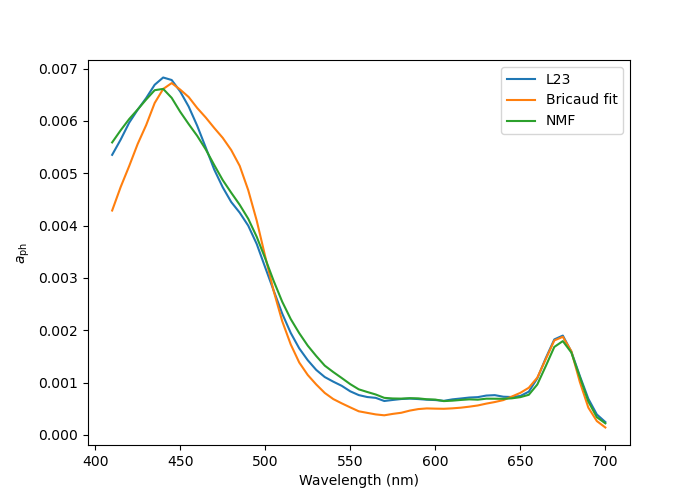

In [50]:
#
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
ax.plot(fit_wave, i_aph, label='L23')
ax.plot(fit_wave, func(fit_wave, ans[0]), label='Bricaud fit')
ax.plot(NMF_wave, recon[idx], label='NMF')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$a_{\rm ph}$')
ax.legend()
#
plt.show()

In [51]:
NMF_wave

array([410., 415., 420., 425., 430., 435., 440., 445., 450., 455., 460.,
       465., 470., 475., 480., 485., 490., 495., 500., 505., 510., 515.,
       520., 525., 530., 535., 540., 545., 550., 555., 560., 565., 570.,
       575., 580., 585., 590., 595., 600., 605., 610., 615., 620., 625.,
       630., 635., 640., 645., 650., 655., 660., 665., 670., 675., 680.,
       685., 690., 695., 700.], dtype=float32)

In [52]:
fit_wave

array([410., 415., 420., 425., 430., 435., 440., 445., 450., 455., 460.,
       465., 470., 475., 480., 485., 490., 495., 500., 505., 510., 515.,
       520., 525., 530., 535., 540., 545., 550., 555., 560., 565., 570.,
       575., 580., 585., 590., 595., 600., 605., 610., 615., 620., 625.,
       630., 635., 640., 645., 650., 655., 660., 665., 670., 675., 680.,
       685., 690., 695., 700.], dtype=float32)